# Demande conditionnelle des facteurs avec contrôles en 2022

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import unicodedata
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

## Chargement des données 

In [3]:
finess = pd.read_csv("finess.csv", sep=";", encoding="utf-8")
sygen = pd.read_csv("SAE/2022/SYGEN_2022r.csv", sep=";", encoding="latin-1")
urg = pd.read_csv("SAE/2022/URGENCES2_2022r.csv", sep=";", encoding="latin-1")
filtre = pd.read_csv("SAE/2022/FILTRE_2022r.csv", sep=";", decimal = ",", encoding="latin-1")
hd = pd.read_csv("Hospidiag/hd2022.csv", sep=";", decimal = ",", encoding="utf-8")

## Fusion des bases

In [4]:
data = sygen[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_DIR','EFF_AUTADM','EFF_INFSANSSPE','SEAN_HEMO_CENTRE','SEAN_CHIMIO',
              'SEAN_RADIO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEJHC_SSR','ENT','EFF_AID','SEJHP_MCO','SEJHC_MCO']]

In [5]:
finess = finess[["FINESS","Raison sociale","Statut Juridique"]]
finess = finess.rename(columns={"FINESS":"FI","Raison sociale":"RS","Statut Juridique":"Statut"})
finess['FI'] = finess['FI'].astype(str)
finess['Statut'] = finess['Statut'].apply(lambda x: unicodedata.normalize('NFC', x) if isinstance(x, str) else x)
data = data.merge(finess, how="left", on = "FI")
data.shape

(3988, 20)

In [6]:
urg = urg[['FI','PASSU']]
urg = urg.groupby('FI').sum().reset_index()
data = data.merge(urg, on="FI", how="left")
data.shape

(3988, 21)

In [7]:
hd = hd[["finess","champ_pmsi","A9"]]
hd = hd.rename(columns={"finess":"FI_EJ"})

#le finess dans hospidiag est le finess géographique pour les établissements avec champ_pmsi OQN ou APs
hd_geo = hd[hd["champ_pmsi"].isin(["OQN", "APs"])] 
hd_geo = hd_geo.rename(columns={"FI_EJ":"FI"})

#le finess dans hospidiag est le finess juridique pour les établissements avec champ_pmsi DGF
hd_jur = hd[hd["champ_pmsi"]=="DGF"]

data = data.merge(hd_jur, how="left", on="FI_EJ")
data = data.merge(hd_geo, how="left", on ="FI")
data.shape


(3988, 25)

In [8]:
filtre = filtre[filtre['STATUT']=='DECLA']
filtre = filtre [["FI","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU"]]
data = data.merge(filtre, how="left", on="FI")
data.shape

(3988, 43)

In [9]:
conjointement_remplies = data[data['A9_x'].notna() & data['A9_y'].notna()]
if len(conjointement_remplies) == 0:
    print("Les colonnes A9_x et 19_y s'excluent mutuellement, comme attendu.")

Les colonnes A9_x et 19_y s'excluent mutuellement, comme attendu.


In [10]:
data['A9'] = data['A9_x'].fillna(data['A9_y'])
data = data.drop(columns=['champ_pmsi_x','champ_pmsi_y','A9_x','A9_y'])
data = data.reset_index()

In [11]:
data['A9'].describe()

count    1643.000000
mean       15.098083
std        14.971543
min         0.000000
25%         4.950000
50%        12.130000
75%        16.220000
max        94.740000
Name: A9, dtype: float64

## Agrégation des personnels 

In [12]:
data['EFF_MED'] = data['EFFSAL_TOT'] + data['EFFLIB_TOT']
data['EFF_ADMIN'] = data['EFF_DIR'] + data['EFF_AUTADM']
data['EFF_IDE'] = data['EFF_INFSANSSPE']

## Agrégation des séances et des séjours en psychiatrie

In [13]:
data.columns

Index(['index', 'FI', 'FI_EJ', 'EFFSAL_TOT', 'EFFLIB_TOT', 'EFF_DIR',
       'EFF_AUTADM', 'EFF_INFSANSSPE', 'SEAN_HEMO_CENTRE', 'SEAN_CHIMIO',
       'SEAN_RADIO', 'SEJ_HTP_TOT', 'VEN_HDJ_TOT', 'VEN_HDN_TOT', 'SEJHC_SSR',
       'ENT', 'EFF_AID', 'SEJHP_MCO', 'SEJHC_MCO', 'RS', 'Statut', 'PASSU',
       'HEB_MED', 'HEB_CHIR', 'HEB_PERINAT', 'HEB_PSY', 'HEB_SSR', 'HEB_SLD',
       'MED', 'CHIRAMBU', 'PSY', 'RTH', 'CHIMIO', 'IRC', 'IVGAMP', 'CPP',
       'HAD', 'SSR', 'URG', 'SMURSAMU', 'A9', 'EFF_MED', 'EFF_ADMIN',
       'EFF_IDE'],
      dtype='object')

In [14]:
data['SEANCES'] = data['SEAN_HEMO_CENTRE'] + data['SEAN_CHIMIO'] + data['SEAN_RADIO']
data['SEJ_PSY'] = data['SEJ_HTP_TOT'] + data['VEN_HDJ_TOT'] + data['VEN_HDN_TOT']
data['SEJ_SSR'] = data['SEJHC_SSR']
data['ENT_SLD'] = data['ENT']

## Passage des variables en log

In [15]:
data["lURG"] = np.where(data["PASSU"] > 0, np.log(data["PASSU"]), 0)
data["lMCO_AMB"] = np.where(data["SEJHP_MCO"] > 0, np.log(data["SEJHP_MCO"]), 0)
data["lMCO_COMP"] = np.where(data["SEJHC_MCO"] > 0, np.log(data["SEJHC_MCO"]), 0)
data["lPSY"] = np.where(data["SEJ_PSY"] > 0, np.log(data["SEJ_PSY"]), 0)
data["lSEANCES"] = np.where(data["SEANCES"] > 0, np.log(data["SEANCES"]), 0)
data["lSSR"] = np.where(data["SEJ_SSR"] > 0, np.log(data["SEJ_SSR"]), 0)
data["lSLD"] = np.where(data["ENT_SLD"] > 0, np.log(data["ENT_SLD"]), 0)

data["lMED"] = np.where(data["EFF_MED"] > 0, np.log(data["EFF_MED"]), 0)
data["lIDE"] = np.where(data["EFF_IDE"] > 0, np.log(data["EFF_IDE"]), 0)
data["lAID"] = np.where(data["EFF_AID"] > 0, np.log(data["EFF_AID"]), 0)
data["lADMIN"] = np.where(data["EFF_ADMIN"] > 0, np.log(data["EFF_ADMIN"]), 0)

c:\Users\Alexandre\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Alexandre\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Alexandre\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Alexandre\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Alexandre\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Alexandre\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide 

## Création des variables de statut

On veut 4 statuts : CHU, petit hôpital public, privé lucratif et privé non lucratif. On a déjà public, privé lucratif et privé non lucratif. On veut donc distinguer petit hôpital public et CHU parmi les hôpitaux publics. Les petits hôpitaux publics (publics mais non CHU) seront notre référence. 

In [16]:
chu = " CHU|CHU "
CHU_data = data[data['RS'].str.contains(chu, na=False)]
data['CHU'] = data['FI'].isin(CHU_data['FI']).astype(int)

In [17]:
data['PL'] = (data['Statut'] == 'Privé lucratif').astype(int)
data['PNL'] = (data['Statut'] == 'Privé non lucratif').astype(int)

In [18]:
data.shape

(3988, 62)

## Imputation des valeurs manquantes pour l'indice de gravité

In [19]:
data['PHP'] = (data[['CHU', 'PNL', 'PL']].sum(axis=1) == 0).astype(int)

types_cols = ['CHU', 'PNL', 'PL', 'PHP'] 
data_renseigne = data[data['A9'].notna()]
frequences = data_renseigne[types_cols].sum().sort_values(ascending=False)
frequences.head()


PHP    1071
PL      455
CHU     101
PNL      16
dtype: int64

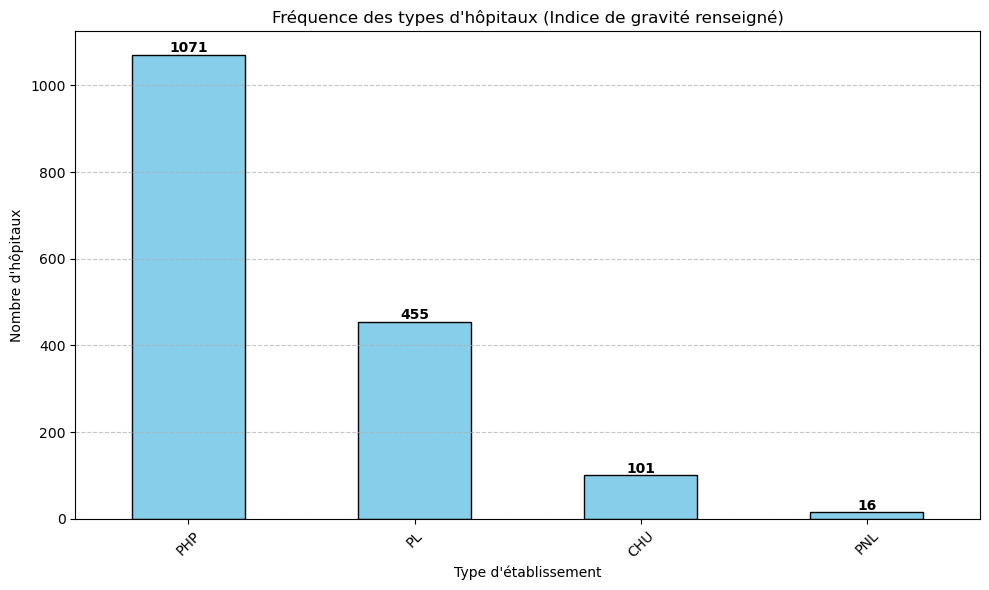

In [20]:
plt.figure(figsize=(10, 6))
frequences.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Fréquence des types d'hôpitaux (Indice de gravité renseigné)")
plt.xlabel("Type d'établissement")
plt.ylabel("Nombre d'hôpitaux")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(frequences):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()

In [21]:
prop_chu_gravite = data[(data['A9'].notna()) & (data['CHU'] == 1)].shape[0] / data[data["CHU"]==1].shape[0]
prop_pl_gravite = data[(data['A9'].notna()) & (data['PL'] == 1)].shape[0] / data[data["PL"]==1].shape[0]
prop_pnl_gravite = data[(data['A9'].notna()) & (data['PNL'] == 1)].shape[0] / data[data["PNL"]==1].shape[0]
prop_php_gravite =  data[(data['A9'].notna()) & (data['PHP'] == 1)].shape[0] / data[data["PHP"]==1].shape[0]

In [22]:
plot_data = pd.DataFrame(
    {'Proportion': [prop_chu_gravite, prop_pl_gravite, prop_pnl_gravite, prop_php_gravite]},
    index=['CHU', 'PL', 'PNL','PHP']
)

<Figure size 1000x600 with 0 Axes>

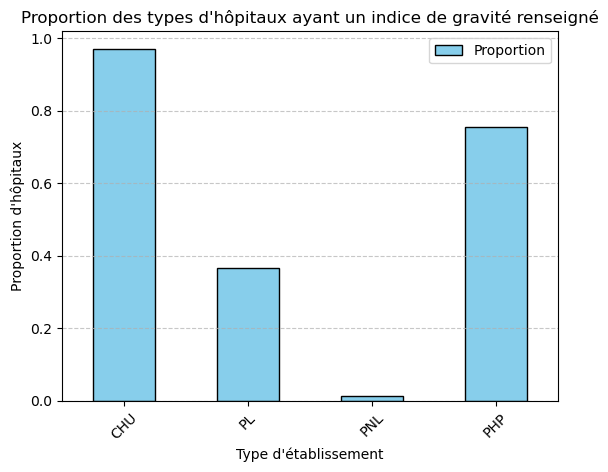

In [23]:
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Proportion des types d'hôpitaux ayant un indice de gravité renseigné")
plt.xlabel("Type d'établissement")
plt.ylabel("Proportion d'hôpitaux")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [24]:
data_cov = data.drop(columns=["FI","FI_EJ","RS",'Statut'])
data_cov.cov()['A9']

index               -2321.561973
EFFSAL_TOT           -180.624974
EFFLIB_TOT           -317.243208
EFF_DIR               -13.288400
EFF_AUTADM           -210.475044
EFF_INFSANSSPE       -523.671543
SEAN_HEMO_CENTRE    -7728.192920
SEAN_CHIMIO          -151.507065
SEAN_RADIO          13003.736875
SEJ_HTP_TOT         -1452.155064
VEN_HDJ_TOT         -6898.462365
VEN_HDN_TOT         -1200.916523
SEJHC_SSR            -387.281879
ENT                   -36.860400
EFF_AID              -266.946714
SEJHP_MCO          -49083.054530
SEJHC_MCO          -31430.981391
PASSU              -19273.288067
HEB_MED                 0.871493
HEB_CHIR               -3.565447
HEB_PERINAT            -1.396037
HEB_PSY                -0.349153
HEB_SSR                 2.880904
HEB_SLD                 1.477321
MED                    -2.045423
CHIRAMBU               -3.657083
PSY                    -0.326920
RTH                    -0.217177
CHIMIO                 -1.783746
IRC                    -0.760614
IVGAMP    

In [25]:
data_knn = data.copy()

missing = 'A9'
cov = ['EFFSAL_TOT', 'EFFLIB_TOT', 'EFF_DIR',
       'EFF_AUTADM', 'EFF_INFSANSSPE', 'SEAN_HEMO_CENTRE', 'SEAN_CHIMIO',
       'SEAN_RADIO', 'SEJ_HTP_TOT', 'VEN_HDJ_TOT', 'VEN_HDN_TOT', 'SEJHC_SSR',
       'ENT', 'EFF_AID', 'SEJHP_MCO', 'SEJHC_MCO', 'PASSU',
       'HEB_MED', 'HEB_CHIR', 'HEB_PERINAT', 'HEB_PSY', 'HEB_SSR', 'HEB_SLD',
       'MED', 'CHIRAMBU', 'PSY', 'RTH', 'CHIMIO', 'IRC', 'IVGAMP', 'CPP',
       'HAD', 'SSR', 'URG', 'SMURSAMU', 'A9', 'EFF_MED', 'EFF_ADMIN',
       'EFF_IDE', 'SEANCES', 'SEJ_PSY', 'SEJ_SSR', 'ENT_SLD', 'lURG',
       'lMCO_AMB', 'lMCO_COMP', 'lPSY', 'lSEANCES', 'lSSR', 'lSLD', 'lMED',
       'lIDE', 'lAID', 'lADMIN']

# Sous-ensemble cible et covariables
cols_pour_knn = [missing] + cov
df_subset = data[cols_pour_knn]

# Normalisation
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_subset)

# KNN
imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled = imputer.fit_transform(df_scaled)

# Dénormalisation et remplacement
df_temp = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=cols_pour_knn)
data['A9_imp'] = df_temp[missing].iloc[:, 0]

Exportation des valeurs imputées :

In [26]:
data[['FI','A9_imp']].to_csv("A9_imputed.csv", index=False)

## Demande conditionnelle de facteurs avec contrôles

In [27]:
outputs = ["lURG", "lMCO_AMB", "lMCO_COMP", "lSSR", "lPSY","lSEANCES", "lSLD"]
controls = ["PNL", "PL", "CHU","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU","A9"]
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]

In [28]:
for cont in controls:
    print(f"{data[cont].isna().sum()} | {cont}")

0 | PNL
0 | PL
0 | CHU
1 | HEB_MED
1 | HEB_CHIR
1 | HEB_PERINAT
1 | HEB_PSY
1 | HEB_SSR
1 | HEB_SLD
1 | MED
1 | CHIRAMBU
1 | PSY
1 | RTH
1 | CHIMIO
1 | IRC
1 | IVGAMP
1 | CPP
1 | HAD
1 | SSR
1 | URG
1 | SMURSAMU
2345 | A9


In [29]:
hd['A9'].isna().sum()

221

In [30]:
results = {}
dict = {}

for var in outputs:
    data[f"{var}_PNL"] = data[var] * data["PNL"]
    data[f"{var}_PL"] = data[var] * data["PL"]
    data[f"{var}_CHU"] = data[var] * data["CHU"]


for inp in inputs:
    X = data[outputs + controls + [f"{v}_PNL" for v in outputs] + [f"{v}_PL" for v in outputs] + [f"{v}_CHU" for v in outputs]]
    X = sm.add_constant(X)
    y = data[inp]
    
    model = sm.OLS(y, X, missing='drop').fit(cov_type="HC1")  # erreurs robustes
    results[inp] = model
    
    print("\n" + "="*60)
    print(f"Demande conditionnelle pour : {inp}")
    print(model.summary())
    
    print(inp)
    for c in ["PL","PNL","CHU"]:
        coef = model.params[c]
        pct = (np.exp(coef) - 1) * 100
        print(f"{c} → différence d'utilisation : {pct:.2f}%")
        dict[(inp,c)] = pct


Demande conditionnelle pour : lMED
                            OLS Regression Results                            
Dep. Variable:                   lMED   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     387.8
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:21:08   Log-Likelihood:                -2939.7
No. Observations:                1643   AIC:                             5973.
Df Residuals:                    1596   BIC:                             6227.
Df Model:                          46                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

c:\Users\Alexandre\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '
c:\Users\Alexandre\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '



Demande conditionnelle pour : lAID
                            OLS Regression Results                            
Dep. Variable:                   lAID   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     106.9
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:21:09   Log-Likelihood:                -1973.0
No. Observations:                1643   AIC:                             4040.
Df Residuals:                    1596   BIC:                             4294.
Df Model:                          46                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     

c:\Users\Alexandre\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '
c:\Users\Alexandre\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 50, but rank is 46
  warnings.warn('covariance of constraints does not have full '


In [31]:
dict

{('lMED', 'PL'): -15.60988018927818,
 ('lMED', 'PNL'): -79.40922014537122,
 ('lMED', 'CHU'): -25.205405496406808,
 ('lIDE', 'PL'): -50.54609586632905,
 ('lIDE', 'PNL'): -99.90548555778099,
 ('lIDE', 'CHU'): -8.323611617567284,
 ('lAID', 'PL'): -76.61661768715771,
 ('lAID', 'PNL'): -99.908719050337,
 ('lAID', 'CHU'): -22.20958099114968,
 ('lADMIN', 'PL'): 104.13686513079949,
 ('lADMIN', 'PNL'): -85.1893896226127,
 ('lADMIN', 'CHU'): 17.81036913619698}

In [32]:
#OK : ajouter indic  HEB_MED, HEB_CHIR,HEB_PERINAT,HEB_PSY,HEB_SSR du fichier filtre (ils sont déjà en indic)

#OK: voir comment traiter USLD car beaucoup de données manquantes : si on l'inclut, ajouter indic ULSD HEB_SLD 
# -> ajouté USLD et indic malgré le manque de données

#OK: rajouter log output x statut juridique 

#OK: rajouter distiction CHU/petit hôpital public, mettre petits hopitaux publics en réf -> comment est ce qu'on fait vu 
#qu'on est au niveau du finess géographique : est ce que les unités appartenant à un CHU sont considérées comme CHU ? je dirais oui

#gros problème : avec le manque de sur l'indice de sévérité, on ne garde que environ 800 observations / 3998...
#est ce qu'on remplace par 0 quand c'est pas renseigné ? est ce qu'on approxime par la moyenne dans le département ? 
#essayer d'imputer par des établissements ressemblants => KNN ?(fait mais à voir si c'est vraiment pertinent)

#faire du log(1+x), quand indicatrice du service = 0, mettre 0 en output dans le service

#ajouter durée de séjour

#est ce qu'on distingue activité psychiatrique à temps complet et à temps partiel ? pour le moment agrégés dans PSY, 
#est ce que le temps partiel correspond à l'ambulatoire ? dans ce cas autant distinguer comme pour MCO ?

## Demande conditionnelle de facteurs avec contrôles et indice de gravité imputé

In [33]:
outputs = ["lURG", "lMCO_AMB", "lMCO_COMP", "lSSR", "lPSY","lSEANCES", "lSLD"]
controls = ["PNL", "PL", "CHU","HEB_MED","HEB_CHIR","HEB_PERINAT","HEB_PSY","HEB_SSR", "HEB_SLD",  
            "MED","CHIRAMBU", "PSY", "RTH", "CHIMIO", "IRC", "IVGAMP", "CPP", "HAD", "SSR","URG","SMURSAMU","A9_imp"]
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]

In [34]:
results = {}
dict = {}

for var in outputs:
    data[f"{var}_PNL"] = data[var] * data["PNL"]
    data[f"{var}_PL"] = data[var] * data["PL"]
    data[f"{var}_CHU"] = data[var] * data["CHU"]


for inp in inputs:
    X = data[outputs + controls + [f"{v}_PNL" for v in outputs] + [f"{v}_PL" for v in outputs] + [f"{v}_CHU" for v in outputs]]
    X = sm.add_constant(X)
    y = data[inp]
    
    model = sm.OLS(y, X, missing='drop').fit(cov_type="HC1")  # erreurs robustes
    results[inp] = model
    
    print("\n" + "="*60)
    print(f"Demande conditionnelle pour : {inp}")
    print(model.summary())
    
    print(inp)
    for c in ["PL","PNL","CHU"]:
        coef = model.params[c]
        pct = (np.exp(coef) - 1) * 100
        print(f"{c} → différence d'utilisation : {pct:.2f}%")
        dict[(inp,c)] = pct


Demande conditionnelle pour : lMED
                            OLS Regression Results                            
Dep. Variable:                   lMED   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     3286.
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:21:09   Log-Likelihood:                -6428.9
No. Observations:                3987   AIC:                         1.296e+04
Df Residuals:                    3936   BIC:                         1.328e+04
Df Model:                          50                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const     